In [ ]:
# === CABECALHO ACADEMICO (gerado por scripts/apply_header.py) ===
# Universidade Presbiteriana Mackenzie
# Disciplina: Inteligência Artificial
# Projeto: Previsão de desempenho de jogadores da NBA (pontos por jogo)
#
# INTEGRANTES DO GRUPO:
#   - Rodrigo Lucas Mascarenhas Leite Oliveira - TIA 10427925
#   - André Ihsan Ward - TIA 10425684
#
# ARQUIVO: notebooks/01_eda.ipynb
# SINTESE: Análise exploratória do dataset.
#
# HISTORICO DE ALTERACOES:
#   data       | autor      | descricao
#   -----------|------------|-------------------------------------------
#   2026-09-14 | grupo      | Versão inicial: coleta, features, alvos, testes e EDA.
# === FIM DO CABECALHO ===


# Analise Exploratoria — Previsao de pontos por jogador na NBA

**Entrega do 1o bimestre.** Este notebook descreve o dataset construido por
`src/collect.py` + `src/build_dataset.py` e sustenta as decisoes de modelagem
que serao executadas no 2o bimestre.

Roteiro:
1. Visao geral e integridade (shape, tipos, periodo, duplicatas)
2. Valores ausentes
3. Alvos: distribuicao de pontos e balanceamento da classe
4. Distribuicoes das features pre-jogo
5. Outliers
6. Correlacoes (e checagem de vazamento)
7. Split temporal — por que **nao** usamos split aleatorio


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import sys; sys.path.insert(0, str(ROOT))
from src.io_utils import read_table
from src.features import PRE_GAME_FEATURES

df = read_table(ROOT / "data" / "processed" / "dataset")
manifest = json.loads((ROOT / "data" / "processed" / "dataset_manifest.json").read_text(encoding="utf-8"))
print(f"{len(df):,} linhas x {df.shape[1]} colunas")
df.head()


83,799 linhas x 37 colunas


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,OPPONENT,GAME_ID,GAME_DATE,SEASON,SEASON_TYPE,IS_PLAYOFF,pts_ma3_prev,pts_ma5_prev,pts_ma10_prev,pts_ewm_prev,pts_std5_prev,pts_season_mean_prev,min_ma3_prev,min_ma5_prev,min_ma10_prev,min_ewm_prev,min_season_mean_prev,fga_ma5_prev,fg3a_ma5_prev,fta_ma5_prev,reb_ma5_prev,ast_ma5_prev,games_played_prev,starter_proxy_prev,rest_days,is_b2b,is_home,opp_def_pts_allowed_prev,opp_pace_proxy_prev,opp_games_played_prev,line_synthetic,y_pts,y_over,split
0,201937,Ricky Rubio,CLE,NYK,0022100140,2021-11-07,2021-22,Regular Season,False,5.333333,8.4,11.4,10.344525,6.730527,11.4,26.000000,27.0,27.6,27.278220,27.6,10.4,4.2,1.8,3.8,5.2,10,0,2.0,0,0,109.000000,222.000000,9,11.5,37,1.0,train
1,202330,Gordon Hayward,CHA,LAC,0022100146,2021-11-07,2021-22,Regular Season,False,18.000000,17.8,18.1,18.205572,8.348653,18.1,33.666667,33.6,34.6,34.451256,34.6,12.4,5.2,2.0,5.4,2.0,10,1,2.0,0,0,102.125000,207.500000,8,20.5,15,0.0,train
2,203082,Terrence Ross,ORL,UTA,0022100141,2021-11-07,2021-22,Regular Season,False,5.000000,5.4,9.4,8.209488,3.049590,9.4,28.000000,26.2,26.5,26.632678,26.5,4.6,2.6,1.6,2.4,2.2,10,0,2.0,0,1,102.111111,215.111111,9,8.5,4,0.0,train
3,203200,Justin Holiday,IND,SAC,0022100143,2021-11-07,2021-22,Regular Season,False,9.666667,10.2,8.9,9.101710,7.155418,8.9,26.000000,28.6,29.2,29.023612,29.2,9.4,7.8,0.0,2.4,2.0,10,1,2.0,0,0,111.000000,224.222222,9,9.0,5,0.0,train
4,203486,Mason Plumlee,CHA,LAC,0022100146,2021-11-07,2021-22,Regular Season,False,4.666667,3.8,6.5,6.086144,2.387467,6.5,22.666667,22.6,26.4,25.543734,26.4,3.8,0.0,2.6,5.6,2.2,10,0,2.0,0,0,102.125000,207.500000,8,6.0,2,0.0,train


## 1. Visao geral e integridade


In [3]:
print("Periodo :", df["GAME_DATE"].min().date(), "->", df["GAME_DATE"].max().date())
print("Temporadas:", sorted(df["SEASON"].unique()))
print("Jogadores :", df["PLAYER_ID"].nunique())
print("Jogos     :", df["GAME_ID"].nunique())

dup = df.duplicated(subset=["PLAYER_ID", "GAME_ID"]).sum()
print("Duplicatas (jogador, jogo):", dup, "<- tem que ser 0 (o grao e jogador-jogo)")

df.dtypes.to_frame("dtype").T


Periodo : 2021-11-07 -> 2026-04-12
Temporadas: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Jogadores : 753
Jogos     : 5430
Duplicatas (jogador, jogo): 0 <- tem que ser 0 (o grao e jogador-jogo)


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,OPPONENT,GAME_ID,GAME_DATE,SEASON,SEASON_TYPE,IS_PLAYOFF,pts_ma3_prev,pts_ma5_prev,pts_ma10_prev,pts_ewm_prev,pts_std5_prev,pts_season_mean_prev,min_ma3_prev,min_ma5_prev,min_ma10_prev,min_ewm_prev,min_season_mean_prev,fga_ma5_prev,fg3a_ma5_prev,fta_ma5_prev,reb_ma5_prev,ast_ma5_prev,games_played_prev,starter_proxy_prev,rest_days,is_b2b,is_home,opp_def_pts_allowed_prev,opp_pace_proxy_prev,opp_games_played_prev,line_synthetic,y_pts,y_over,split
dtype,int64,str,str,str,str,datetime64[us],str,str,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,Int64,float64,Int64,Int64,float64,float64,int64,float64,int64,float64,str


,linhas,jogadores,pts_medio
SEASON,,,
2021-22,16881,449,12.54
2022-23,16616,417,13.14
2023-24,16548,420,13.14
2024-25,16653,440,12.95
2025-26,17101,450,12.73


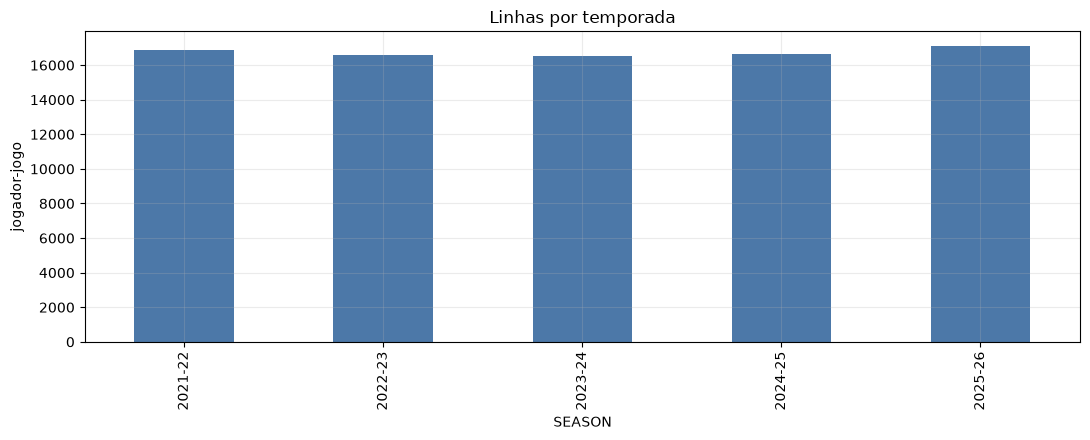

In [4]:
# Volume por temporada — checa se alguma temporada esta truncada.
por_season = df.groupby("SEASON").agg(
    linhas=("y_pts", "size"), jogadores=("PLAYER_ID", "nunique"),
    pts_medio=("y_pts", "mean"),
).round(2)
display(por_season)

por_season["linhas"].plot(kind="bar", title="Linhas por temporada", color="#4c78a8")
plt.ylabel("jogador-jogo"); plt.tight_layout(); plt.show()


## 2. Valores ausentes

Nulos aqui **nao sao defeito**: sao consequencia direta da regra anti-vazamento.
Nos primeiros jogos de um jogador em cada temporada nao existe passado para
calcular media movel, entao a feature e nula por construcao. O que precisamos
verificar e se o padrao de nulos e o esperado (concentrado no inicio de
temporada) e nao aleatorio.


In [5]:
feats = [c for c in PRE_GAME_FEATURES if c in df.columns]
nulos = df[feats].isna().sum().sort_values(ascending=False)
nulos = (pd.DataFrame({"nulos": nulos, "pct": (nulos / len(df) * 100).round(2)})
         .query("nulos > 0"))
display(nulos)

if not nulos.empty:
    nulos["pct"].plot(kind="barh", title="% de nulos por feature", color="#e45756")
    plt.xlabel("%"); plt.tight_layout(); plt.show()
else:
    print("Sem nulos nas features (o filtro de min_minutes_prev ja removeu o inicio de temporada).")


,nulos,pct


Sem nulos nas features (o filtro de min_minutes_prev ja removeu o inicio de temporada).


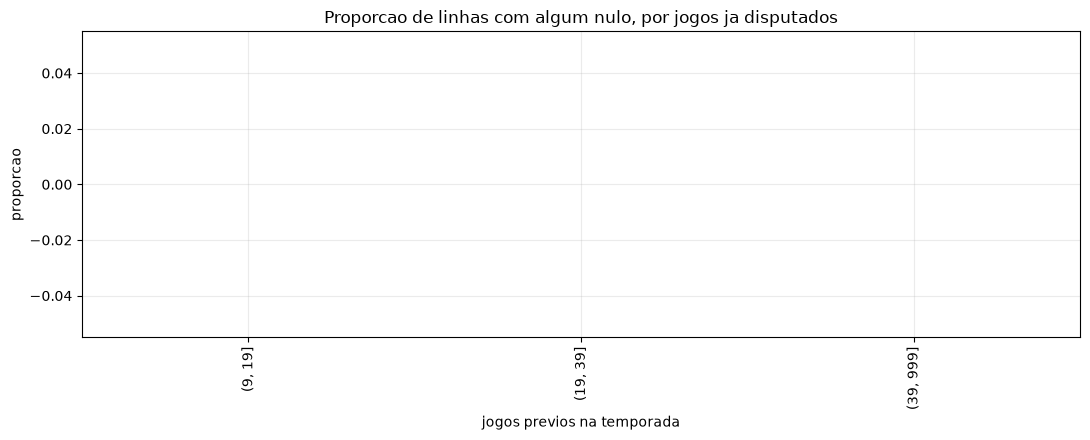

In [6]:
# Os nulos se concentram no inicio da temporada do jogador?
tmp = df.copy()
tmp["tem_nulo"] = tmp[feats].isna().any(axis=1)
perfil = tmp.groupby(pd.cut(tmp["games_played_prev"], [-1, 4, 9, 19, 39, 999]))["tem_nulo"].mean()
perfil.plot(kind="bar", title="Proporcao de linhas com algum nulo, por jogos ja disputados", color="#f58518")
plt.ylabel("proporcao"); plt.xlabel("jogos previos na temporada"); plt.tight_layout(); plt.show()


## 3. Alvos


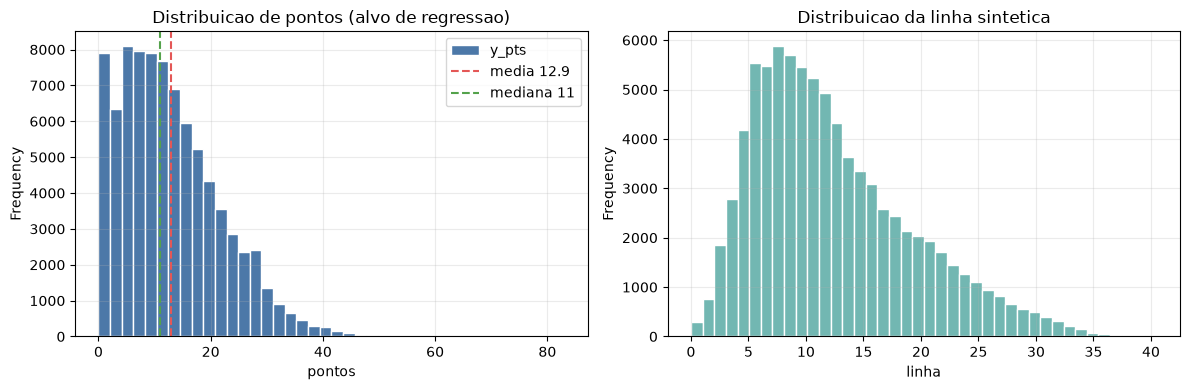

count    83799.0
mean        12.9
std          8.8
min          0.0
25%          6.0
50%         11.0
75%         18.0
max         83.0
Name: y_pts, dtype: float64

Assimetria (skew): 0.882 - cauda a direita e esperada em pontos


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["y_pts"].plot(kind="hist", bins=40, ax=ax[0], color="#4c78a8", edgecolor="white")
ax[0].set_title("Distribuicao de pontos (alvo de regressao)"); ax[0].set_xlabel("pontos")
ax[0].axvline(df["y_pts"].mean(), color="#e45756", ls="--", label=f"media {df['y_pts'].mean():.1f}")
ax[0].axvline(df["y_pts"].median(), color="#54a24b", ls="--", label=f"mediana {df['y_pts'].median():.0f}")
ax[0].legend()

df["line_synthetic"].plot(kind="hist", bins=40, ax=ax[1], color="#72b7b2", edgecolor="white")
ax[1].set_title("Distribuicao da linha sintetica"); ax[1].set_xlabel("linha")
plt.tight_layout(); plt.show()

print(df["y_pts"].describe().round(2))
print("\nAssimetria (skew):", round(df["y_pts"].skew(), 3), "- cauda a direita e esperada em pontos")


Classe positiva (superou a linha): 48.3%
Classe negativa                  : 51.7%

Baseline de acuracia chutando sempre a classe majoritaria: 51.7%


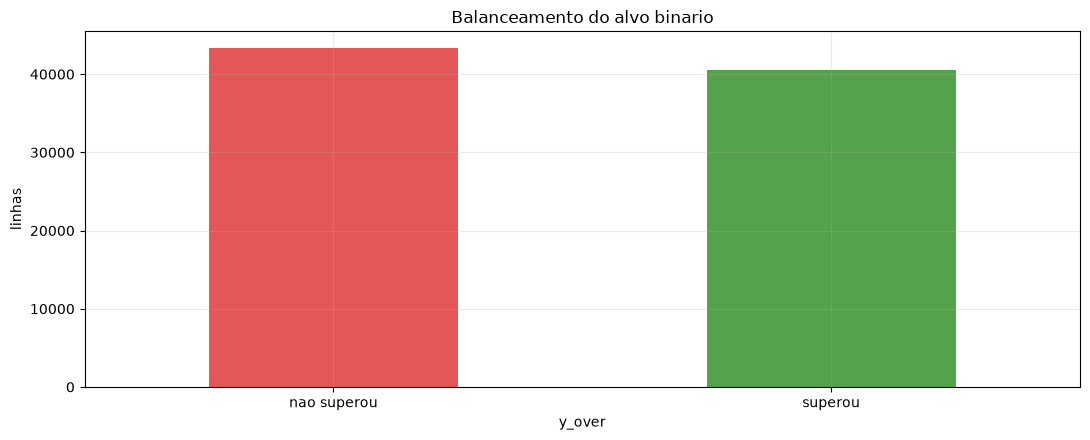

In [8]:
# Balanceamento da classe.
prop = df["y_over"].mean()
print(f"Classe positiva (superou a linha): {prop:.1%}")
print(f"Classe negativa                  : {1-prop:.1%}")
print("\nBaseline de acuracia chutando sempre a classe majoritaria:", f"{max(prop, 1-prop):.1%}")

df["y_over"].value_counts().sort_index().plot(
    kind="bar", title="Balanceamento do alvo binario", color=["#e45756", "#54a24b"])
plt.xticks([0, 1], ["nao superou", "superou"], rotation=0); plt.ylabel("linhas")
plt.tight_layout(); plt.show()


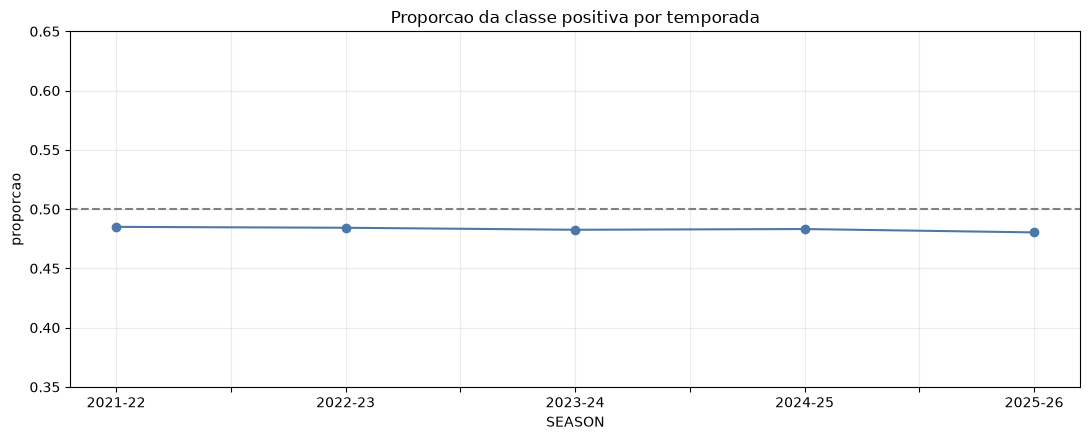

In [9]:
# O balanceamento se mantem ao longo do tempo? (Se derivar, o modelo sofre drift.)
df.groupby("SEASON")["y_over"].mean().plot(
    kind="line", marker="o", title="Proporcao da classe positiva por temporada", color="#4c78a8")
plt.axhline(0.5, color="gray", ls="--"); plt.ylim(0.35, 0.65); plt.ylabel("proporcao")
plt.tight_layout(); plt.show()


## 4. Distribuicoes das features pre-jogo


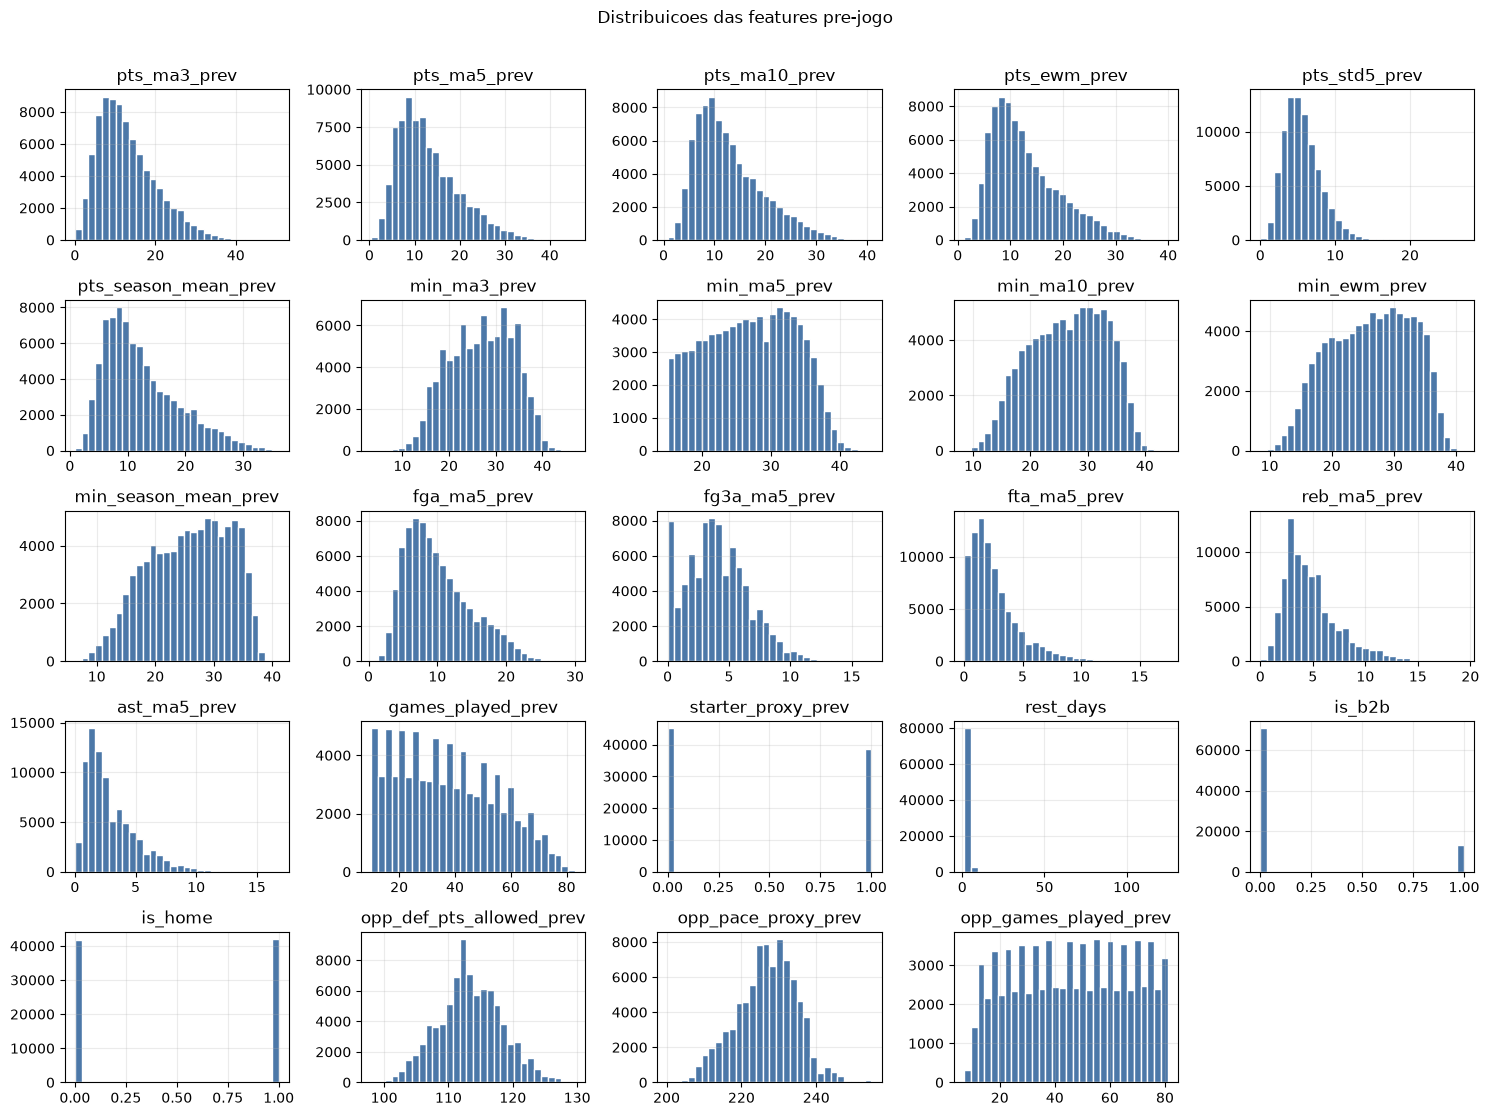

In [10]:
num = [c for c in feats if pd.api.types.is_numeric_dtype(df[c])]
df[num].hist(bins=30, figsize=(15, 11), color="#4c78a8", edgecolor="white")
plt.suptitle("Distribuicoes das features pre-jogo", y=1.01)
plt.tight_layout(); plt.show()


In [11]:
display(df[num].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
pts_ma3_prev,83799.0,13.036759,7.13682,0.0,7.666667,11.666667,17.0,50.666667
pts_ma5_prev,83799.0,13.014053,6.741034,0.4,8.0,11.6,17.0,45.6
pts_ma10_prev,83799.0,12.84281,6.52428,0.8,7.9,11.4,16.6,40.8
pts_ewm_prev,83799.0,12.724426,6.398821,1.175331,7.867915,11.226537,16.456717,39.903058
pts_std5_prev,83799.0,5.59972,2.486155,0.0,3.781534,5.244044,6.9857,27.226825
pts_season_mean_prev,83799.0,12.341928,6.390761,0.866667,7.480769,10.847458,16.108117,36.125
min_ma3_prev,83799.0,26.907012,6.788672,3.333333,21.666667,27.333333,32.333333,47.0
min_ma5_prev,83799.0,26.86038,6.423406,15.0,21.6,27.0,32.2,44.6
min_ma10_prev,83799.0,26.496848,6.549024,8.4,21.3,26.9,31.9,44.0
min_ewm_prev,83799.0,26.292329,6.460526,8.507255,21.074522,26.672612,31.654495,41.264606


## 5. Outliers

Tratamos outliers com cuidado: um jogo de 60 pontos e raro, mas **e real** e
faz parte do fenomeno. Nao vamos remover — vamos apenas identificar o volume e
decidir no 2o bimestre entre transformacao (log/winsorizacao) ou modelo robusto.


,% outliers (IQR)
is_b2b,15.71
rest_days,6.32
fta_ma5_prev,4.58
reb_ma5_prev,4.37
ast_ma5_prev,3.55
pts_std5_prev,1.96
pts_ma3_prev,1.87
pts_ma5_prev,1.77
pts_ma10_prev,1.72
pts_ewm_prev,1.66


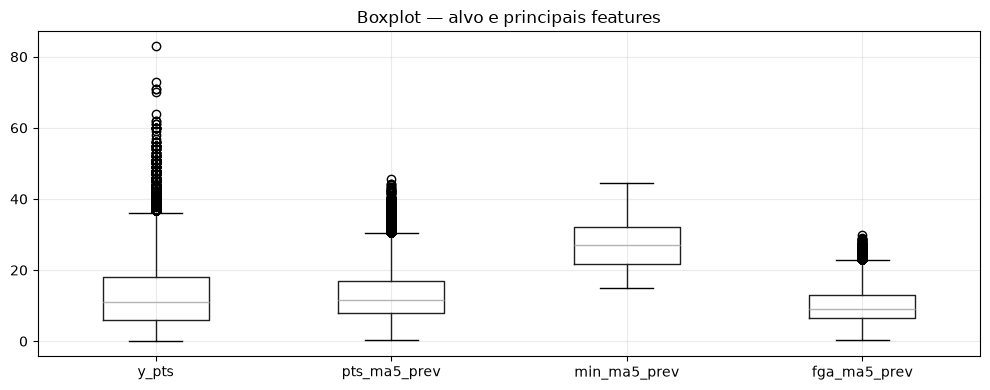

In [12]:
def iqr_outliers(s: pd.Series) -> float:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((s < lo) | (s > hi)).mean() * 100)

taxa = pd.Series({c: iqr_outliers(df[c].dropna()) for c in num}).sort_values(ascending=False)
display(taxa.to_frame("% outliers (IQR)").round(2).head(12))

df.boxplot(column=["y_pts", "pts_ma5_prev", "min_ma5_prev", "fga_ma5_prev"], figsize=(10, 4))
plt.title("Boxplot — alvo e principais features"); plt.tight_layout(); plt.show()


In [13]:
print("Jogos de 50+ pontos:", int((df["y_pts"] >= 50).sum()))
display(df.nlargest(8, "y_pts")[["PLAYER_NAME", "GAME_DATE", "OPPONENT", "y_pts", "line_synthetic"]])


Jogos de 50+ pontos: 88


,PLAYER_NAME,GAME_DATE,OPPONENT,y_pts,line_synthetic
79575,Bam Adebayo,2026-03-10,WAS,83,23.5
41359,Luka Dončić,2024-01-26,ATL,73,34.0
22901,Donovan Mitchell,2023-01-02,CHI,71,26.5
28512,Damian Lillard,2023-02-26,HOU,71,38.5
40865,Joel Embiid,2024-01-22,SAS,70,38.0
36205,Giannis Antetokounmpo,2023-12-13,IND,64,32.5
40870,Karl-Anthony Towns,2024-01-22,CHA,62,22.5
41321,Devin Booker,2024-01-26,IND,62,25.0


## 6. Correlacoes

Dois objetivos: (a) entender quais features carregam sinal; (b) **checar
vazamento** — nenhuma feature pre-jogo pode ter correlacao quase perfeita com o
alvo do mesmo jogo. Se tiver, e porque informacao do futuro entrou.


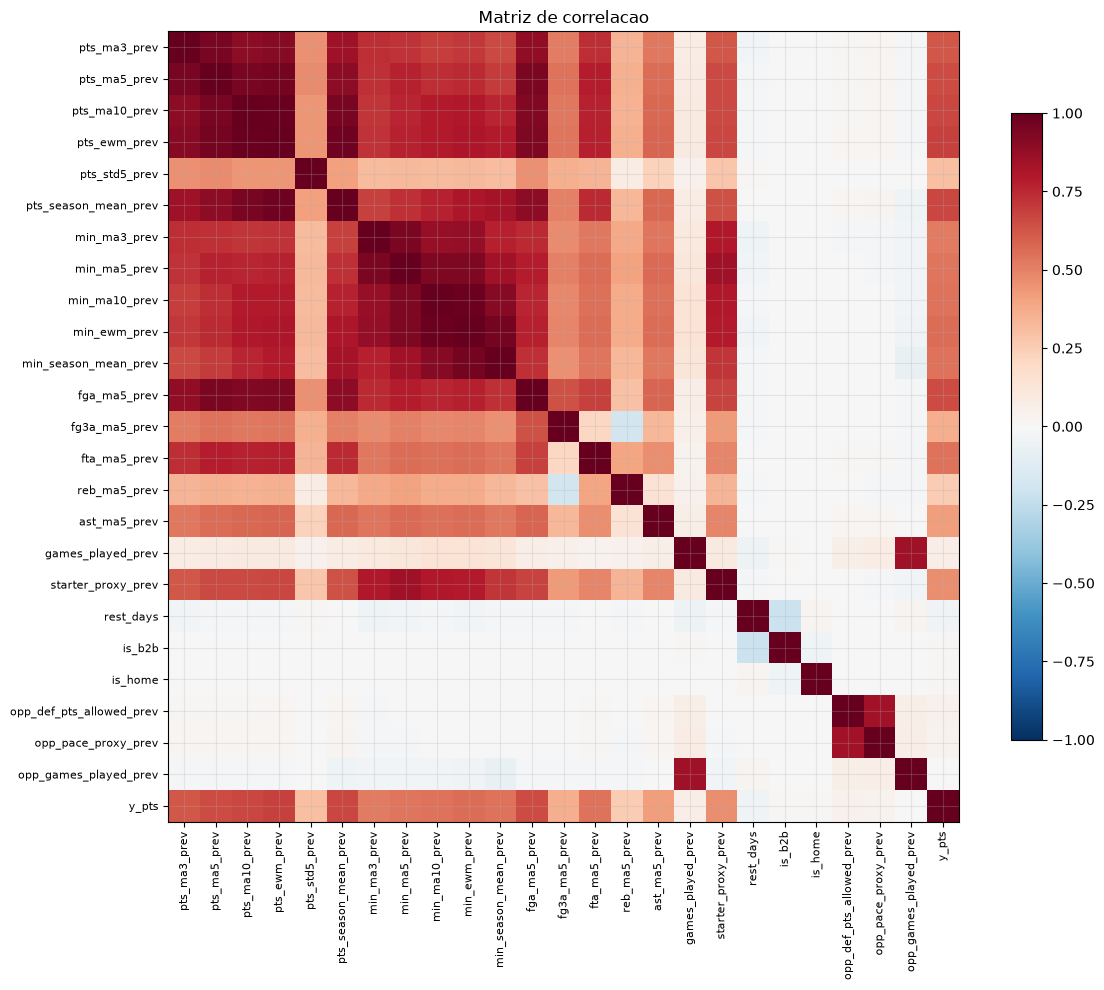

In [14]:
corr = df[num + ["y_pts"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im, fraction=0.03); plt.title("Matriz de correlacao"); plt.tight_layout(); plt.show()


In [15]:
alvo = corr["y_pts"].drop("y_pts").sort_values(ascending=False)
display(alvo.to_frame("corr com y_pts").round(3))

suspeitas = alvo[alvo.abs() > 0.95]
print("\nFeatures com |corr| > 0.95 (suspeita de vazamento):",
      "NENHUMA - ok" if suspeitas.empty else list(suspeitas.index))


,corr com y_pts
pts_ewm_prev,0.682
pts_season_mean_prev,0.671
pts_ma10_prev,0.670
fga_ma5_prev,0.650
pts_ma5_prev,0.649
pts_ma3_prev,0.623
min_ewm_prev,0.559
min_ma10_prev,0.545
min_season_mean_prev,0.541
fta_ma5_prev,0.540



Features com |corr| > 0.95 (suspeita de vazamento): NENHUMA - ok


In [16]:
# Multicolinearidade: medias moveis da mesma stat sao naturalmente redundantes.
alta = (corr.where(~np.eye(len(corr), dtype=bool)).abs().stack()
        .sort_values(ascending=False).drop_duplicates())
display(alta[alta > 0.9].to_frame("|corr|").head(15).round(3))
print("\nPares muito correlacionados sao esperados (ma3/ma5/ma10 da mesma stat).")
print("No 2o bimestre: regularizacao (L1/L2) ou selecao de features resolve.")


|corr|
pts_ewm_prev         pts_ma10_prev          0.988
min_ewm_prev         min_ma10_prev          0.983
pts_season_mean_prev pts_ewm_prev           0.976
min_season_mean_prev min_ewm_prev           0.958
pts_ma5_prev         pts_ewm_prev           0.955
pts_ma10_prev        pts_ma5_prev           0.951
                     pts_season_mean_prev   0.949
pts_ma5_prev         pts_ma3_prev           0.947
min_ma5_prev         min_ma3_prev           0.944
pts_ma5_prev         fga_ma5_prev           0.941
min_ma5_prev         min_ma10_prev          0.937
                     min_ewm_prev           0.935
fga_ma5_prev         pts_ewm_prev           0.933
pts_ma10_prev        fga_ma5_prev           0.927
min_ma10_prev        min_season_mean_prev   0.910


Pares muito correlacionados sao esperados (ma3/ma5/ma10 da mesma stat).
No 2o bimestre: regularizacao (L1/L2) ou selecao de features resolve.


## 7. Split temporal

**Nao usamos split aleatorio.** Num dataset de series temporais esportivas, o
split aleatorio coloca o jogo de 12/01 no teste e o de 13/01 no treino. Como as
features sao medias moveis do proprio jogador, o modelo treina com o estado
futuro daquele mesmo jogador e "ve o futuro" — a metrica sobe e o modelo nao
generaliza para a proxima temporada, que e o cenario real de uso.

Proposta (ja materializada na coluna `split`):

| Split | Temporadas | Papel |
|---|---|---|
| `train` | 2021-22, 2022-23, 2023-24 | ajuste dos parametros |
| `val`   | 2024-25 | selecao de modelo e hiperparametros |
| `test`  | 2025-26 | avaliacao final, tocado **uma vez** |

Para o 2o bimestre: validacao cruzada temporal (`TimeSeriesSplit`) dentro do
treino, respeitando a ordem cronologica.


,linhas,inicio,fim,jogadores,classe_positiva
split,,,,,
train,50045,2021-11-07,2024-04-14,589,0.484
val,16653,2024-11-09,2025-04-13,440,0.483
test,17101,2025-11-09,2026-04-12,450,0.480


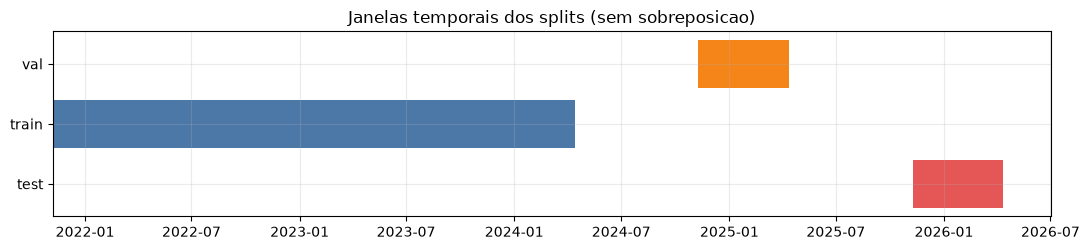

In [17]:
resumo = df.groupby("split").agg(
    linhas=("y_pts", "size"),
    inicio=("GAME_DATE", "min"), fim=("GAME_DATE", "max"),
    jogadores=("PLAYER_ID", "nunique"),
    classe_positiva=("y_over", "mean"),
)
resumo["classe_positiva"] = resumo["classe_positiva"].round(3)
display(resumo.loc[[s for s in ["train", "val", "test"] if s in resumo.index]])

# Prova visual de que os splits nao se sobrepoem no tempo.
fig, ax = plt.subplots(figsize=(11, 2.6))
cores = {"train": "#4c78a8", "val": "#f58518", "test": "#e45756"}
for i, (nome, g) in enumerate(df.groupby("split")):
    ax.barh(nome, (g["GAME_DATE"].max() - g["GAME_DATE"].min()).days,
            left=g["GAME_DATE"].min(), color=cores.get(nome, "gray"))
ax.set_title("Janelas temporais dos splits (sem sobreposicao)")
plt.tight_layout(); plt.show()


In [18]:
# Checagem dura: nenhum jogo do treino pode ser posterior ao inicio do teste.
if {"train", "test"}.issubset(set(df["split"])):
    fim_treino = df.loc[df["split"] == "train", "GAME_DATE"].max()
    ini_teste = df.loc[df["split"] == "test", "GAME_DATE"].min()
    print("fim do treino :", fim_treino.date())
    print("inicio do teste:", ini_teste.date())
    assert fim_treino < ini_teste, "VAZAMENTO: treino invade o periodo de teste"
    print("\nOK - splits estritamente ordenados no tempo.")


fim do treino : 2024-04-14
inicio do teste: 2025-11-09

OK - splits estritamente ordenados no tempo.


## Conclusoes para o 2o bimestre

1. **Alvo.** A classificacao contra a linha sintetica fica ~50/50, entao acuracia
   simples ja e informativa (baseline de chute = ~50%). Reportar tambem AUC e
   Brier score, que capturam qualidade da probabilidade, nao so do corte.
2. **Nulos.** Concentrados no inicio da temporada de cada jogador, por construcao.
   Ou se descarta o comeco (feito, via `min_minutes_prev`) ou se imputa com a
   media da temporada anterior — nunca com a media global, que vazaria.
3. **Outliers.** Manter. Jogos de 50+ pontos sao raros e reais; avaliar
   winsorizacao apenas se o erro do modelo for dominado por eles.
4. **Multicolinearidade.** ma3/ma5/ma10 da mesma stat sao redundantes: usar
   regularizacao ou escolher uma janela por familia.
5. **Validacao.** Split temporal ja definido; usar `TimeSeriesSplit` no treino.
6. **Baselines obrigatorias** antes de qualquer modelo sofisticado:
   - regressao: prever `pts_ma5_prev` (a media recente) e medir MAE;
   - classificacao: prever sempre a classe majoritaria.
   Um modelo so se justifica se superar essas duas.
